*Subject*: Data Science\
*Author*: Luz Enseñat de Carlos



# Dimensionality Reduction in Iris and MNIST



## Principal Components Analysis (PCA)

In the following Project we will use the `Iris` dataset to obtain a new representation of the data in a lower-dimensional space than the original one.

In [65]:
# We load the libraries:

%matplotlib inline

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris


# We load the dataset from sklearn:

iris = datasets.load_iris()



The dataset contains data about three iris plants (iris setosa, iris versicolour, and iris virginica), described using four attributes:

1. Sepal length (cm)
2. Sepal width (cm)
3. Petal length (cm)
4. Petal width (cm)



We assign the data and labels to different variables.

In [66]:
# We separate features and labels and see how many features we have:

features = iris.data
label = iris.target
print (features.shape)

(150, 4)


In [67]:
# Since what we have is a sklearn array with 4 features, we create a DataFrame for visual exploration:

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# We also add the class column (target), already labeled:

df['target'] = iris.target

# We show the mapping from target (index) to species name to know which one is which:

for i, name in enumerate(iris.target_names):
    print(f"{i}: {name}")

df.head(5)

0: setosa
1: versicolor
2: virginica


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


We perform an exploratory analysis of the data. We plot the variables pairwise, coloring each point according to the plant class to see how they differ.

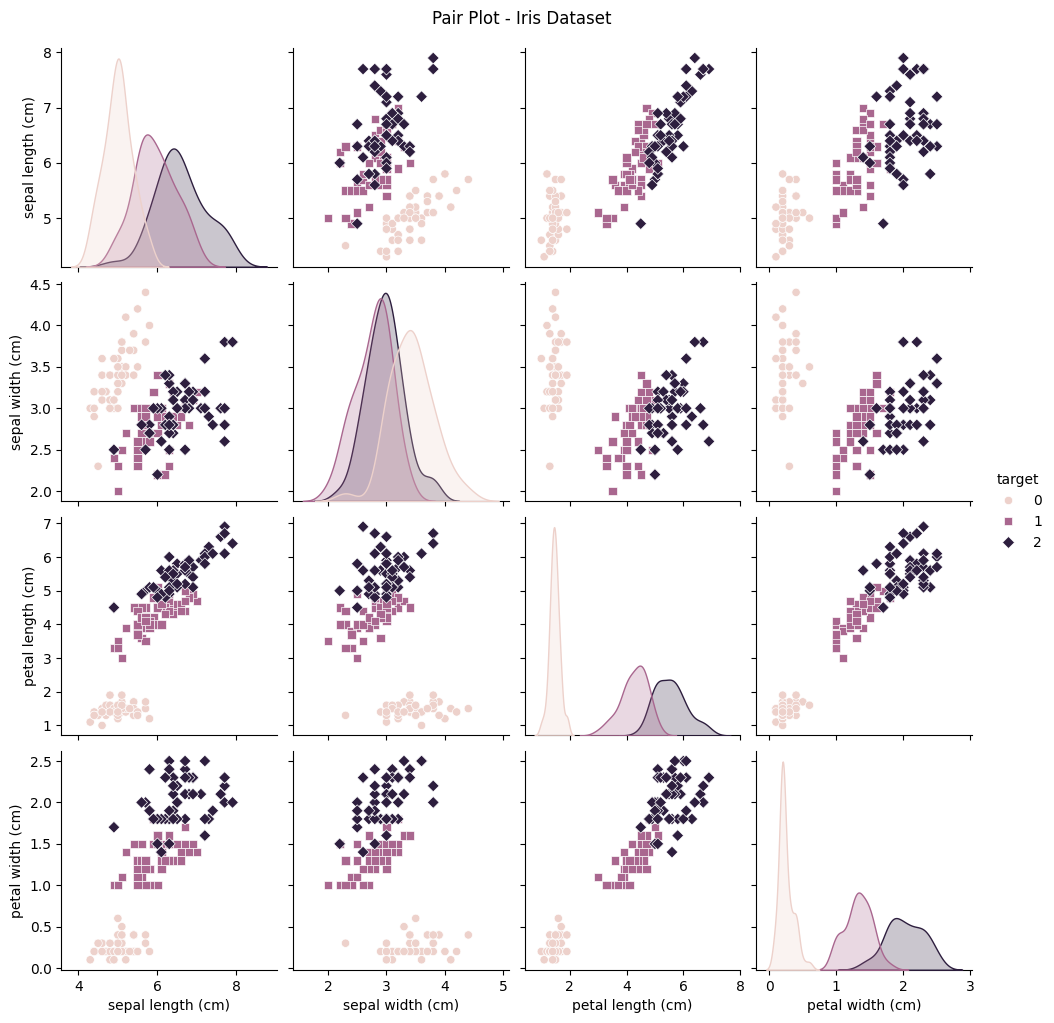

In [68]:
# We plot the variables pairwise:

sns.pairplot(df, hue='target', diag_kind='kde', markers=["o", "s", "D"])
plt.suptitle("Pair Plot - Iris Dataset", y=1.02)
plt.show()

Looking at the graphs, it is clear that the setosa species differs from the other two, while versicolor and virginica are more similar.

In [69]:
# We analyze the variables and check whether they move in different ranges to assess the need to normalize the data:

df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


We see that we need to scale the data, especially because we are going to apply PCA next, so we are going to normalize it.

In [70]:
# We define only the features, without the target, to normalize the data:

features = [x for x in df.columns if x!= 'target']

df [features].head (5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [71]:
# We apply StandardScaler to normalize the feature data:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_scaled.shape

(150, 4)

In [72]:
# We convert the array obtained after normalization into a DataFrame to visualize it better, although for PCA we will work with the array:

df_scaled = pd.DataFrame (X_scaled, columns = features)
df_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [73]:
# We verify through a description that they have mean 0 and standard deviation 1 (after normalization with StandardScaler):

df_scaled.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.43,-1.57,-1.45
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.49,3.09,1.79,1.71




## Application

We use the `PCA` module from Scikit-learn, which contains the necessary methods to obtain the principal components of a dataset and transform them into the new representation space.



Using the iris dataset, we are going to extract the three principal components and then transform the dataset into the new attribute representation space.
The code is provided.





The process can be broken down into three stages
1. Create the PCA object
2. Extract the principal components
3. Transform the data

In [74]:
# We create the PCA object with 3 components:

pca3 = PCA(n_components=3)
pca3.fit(X_scaled)
X_scaled_reduced_3 = pca3.transform(X_scaled)

# We verify that it has shape (150, 3):

print (X_scaled_reduced_3.shape)

(150, 3)


 Next, we generate a graph with the transformed data.

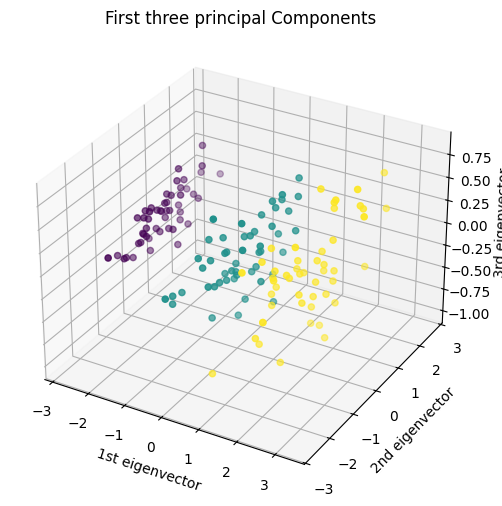

Explained Variance: [0.72962445 0.22850762 0.03668922]


In [75]:
# We create a 3D graph:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# We assign the labels:

sc = ax.scatter(X_scaled_reduced_3[:, 0], X_scaled_reduced_3[:, 1], X_scaled_reduced_3[:, 2], c=label)
ax.set_title("First three principal Components")
ax.set_xlabel("1st eigenvector")
ax.set_ylabel("2nd eigenvector")
ax.set_zlabel("3rd eigenvector")

# We print the graph:

plt.show()

# We print the explained variance:

print("Explained Variance:", pca3.explained_variance_ratio_)


The `n_components` attribute indicates the number of principal components that we want to use to reduce the dimensionality of the dataset. We reduce the dataset to two dimensions and plot the data in these two new dimensions.



To reduce to two dimensions, we simply need to modify the `n_components = 2` attribute

In [76]:
# We create the PCA object with 2 components:

pca2 = PCA(n_components=2)
pca2.fit(X_scaled)
X_scaled_reduced_2 = pca2.transform(X_scaled)

# We verify that it has shape (150, 2):

print (X_scaled_reduced_2.shape)

(150, 2)


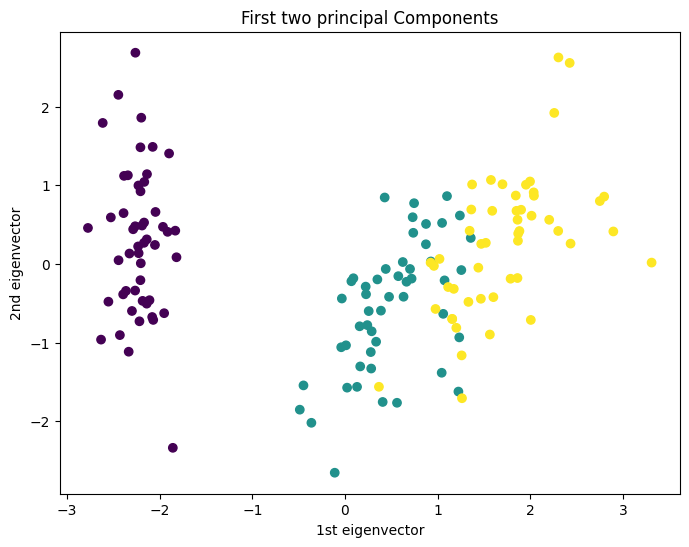

In [77]:
# We create a 2D graph:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# We assign the labels:

sc = ax.scatter(X_scaled_reduced_2[:, 0], X_scaled_reduced_2[:, 1], c=label)
ax.set_title("First two principal Components")
ax.set_xlabel("1st eigenvector")
ax.set_ylabel("2nd eigenvector")

# We print the graph:

plt.show()



To choose k, a good number of principal components is considered to be the smallest value of k that retains 99% of the variance.



In Scikit-learn, we can obtain the percentage of variance explained by each principal component with the attribute:

```python
PCA.explained_variance_ratio_
```

We are going to take a PCA with all possible components, that is, as many as variables the initial dataset has

In [78]:
# We apply PCA with all components:

pca4 = PCA(n_components=4)
pca4.fit(X_scaled)

# We obtain the explained variance and cumulative explained variance:

explained_var = pca4.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# We show the results:

for i, (var, cum_var) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"Component {i}: {var:.4f} (Accumulated: {cum_var:.4f})")

# We see how many components we need to reach 99%:

k = np.argmax(cumulative_var >= 0.99) + 1
print(f"\nMinimum number of components to retain ≥99% of the variance: {k}")

Component 1: 0.7296 (Accumulated: 0.7296)
Component 2: 0.2285 (Accumulated: 0.9581)
Component 3: 0.0367 (Accumulated: 0.9948)
Component 4: 0.0052 (Accumulated: 1.0000)

Minimum number of components to retain ≥99% of the variance: 3


We will now plot the explained variance for each component and the cumulative variance.

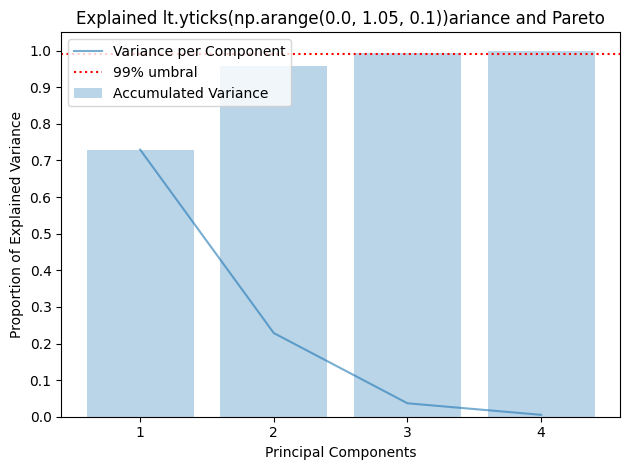

In [79]:
# We plot the Explained Variance and the Cumulative Explained Variance:

plt.plot(range(1,5),explained_var, alpha=0.6, label='Variance per Component')
plt.bar(range(1,5), cumulative_var, alpha=.3, label='Accumulated Variance')
plt.axhline(y=0.99, color='r', linestyle=':', label='99% umbral')
plt.title("Explained lt.yticks(np.arange(0.0, 1.05, 0.1))ariance and Pareto")
plt.xlabel('Principal Components')
plt.ylabel('Proportion of Explained Variance')
plt.xticks(range(1, 5))
plt.yticks(np.arange(0.0, 1.05, 0.1))
plt.tight_layout()
plt.legend()
plt.show()

The first component already explains more than 92% of the variance but, since we need a minimum of 99%, we will have to choose 3 components, as can be seen in the graph.

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

Next, we are going to perform dimensionality reduction with another method: t-SNE. This method is an unsupervised and non-linear dimensionality reduction technique based on the t-Student probability distribution.

We will now work with the MNIST dataset, which we will load directly from scikit-learn. The MNIST dataset is one of the most popular and widely used datasets in the field of machine learning and computer vision. MNIST (Modified National Institute of Standards and Technology) consists of a set of grayscale images of handwritten digits, from 0 to 9, collected from various documents from employees of the United States Census Bureau and high school students.

#### MNIST data

In [80]:
from sklearn.datasets import load_digits

# We load the MNIST-like dataset:

digits = load_digits()

# We access the data and target labels:

X = digits.data
y = digits.target

print(X.shape, y.shape)

(1797, 64) (1797,)


We transform the data matrix into a DataFrame. Simply run the code provided below.

In [81]:
feat_cols = [ 'pixel'+str(i) for i in range(X.shape[1]) ]

df = pd.DataFrame(X,columns=feat_cols)
df['y'] = y
df['label'] = df['y'].apply(lambda i: str(i))

print('Size of the dataframe: {}'.format(df.shape))
df.head()

Size of the dataframe: (1797, 66)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,y,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4,4


#### PCA

First, we perform dimensionality reduction using PCA on the MNIST dataset. We first standardize the data and reduce it to two components.

We draw a scatter plot representing this reduction on the two principal components.

We color each point according to the number it represents, that is, the y variable or label in the case of the DataFrame.

In [82]:
# We define only the features, without the target ("y" and "label"), to normalize the data:

features = [x for x in df.columns if x!= 'y' if x!= 'label']

df [features].head (5)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [83]:
# We standardize the feature data using StandardScaler:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_scaled.shape

(1797, 64)

In [84]:
# We convert the array obtained after normalization into a DataFrame to visualize it better, although for PCA we will work with the array:

df_scaled = pd.DataFrame (X_scaled, columns = features)
df_scaled

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
0,0.0,-0.335016,-0.043081,0.274072,-0.664478,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,0.086719,0.208293,-0.366771,-1.146647,-0.505670,-0.196008
1,0.0,-0.335016,-1.094937,0.038648,0.268751,-0.138020,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-0.249010,0.849632,0.548561,-0.505670,-0.196008
2,0.0,-0.335016,-1.094937,-1.844742,0.735366,1.097673,-0.409724,-0.125023,-0.059078,-0.624009,...,0.259230,-0.209785,-0.023596,-0.299081,-1.089383,-2.078218,-0.164037,1.565686,1.695137,-0.196008
3,0.0,-0.335016,0.377661,0.744919,0.268751,-0.844129,-0.409724,-0.125023,-0.059078,1.879691,...,1.072563,-0.209785,-0.023596,-0.299081,0.282736,0.208293,0.241430,0.379040,-0.505670,-0.196008
4,0.0,-0.335016,-1.094937,-2.551014,-0.197863,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-2.306869,0.849632,-0.468564,-0.505670,-0.196008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,-0.335016,-0.253452,-0.432200,0.268751,0.038508,-0.409724,-0.125023,-0.059078,-0.311047,...,0.055897,-0.209785,-0.023596,-0.299081,-0.697349,0.436944,0.646898,0.379040,-0.505670,-0.196008
1793,0.0,-0.335016,0.167290,0.980343,0.268751,0.921145,-0.108958,-0.125023,-0.059078,-0.624009,...,-0.554103,-0.209785,-0.023596,-0.299081,0.086719,0.894246,0.444164,-0.129523,-0.505670,-0.196008
1794,0.0,-0.335016,-0.884566,-0.196776,0.735366,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-0.697349,-0.706312,0.241430,-0.129523,-0.505670,-0.196008
1795,0.0,-0.335016,-0.674195,-0.432200,-1.131092,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.350769,-0.209785,-0.023596,-0.299081,-0.109298,-0.020358,0.849632,0.887602,-0.505670,-0.196008


In [85]:
# We verify through a description that the features we see have mean 0 and standard deviation 1 (after normalization with StandardScaler):

df_scaled.describe().round(2)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63
count,1797.0,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,...,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00
mean,0.0,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,...,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.0,-0.34,-1.09,-2.79,-2.76,-1.02,-0.41,-0.13,-0.06,-0.62,...,-0.76,-0.21,-0.02,-0.30,-1.09,-2.76,-2.39,-1.15,-0.51,-0.20
25%,0.0,-0.34,-0.88,-0.43,-0.43,-1.02,-0.41,-0.13,-0.06,-0.62,...,-0.76,-0.21,-0.02,-0.30,-0.89,-0.25,-0.37,-1.15,-0.51,-0.20
50%,0.0,-0.34,-0.25,0.27,0.27,-0.31,-0.41,-0.13,-0.06,-0.62,...,-0.55,-0.21,-0.02,-0.30,-0.31,0.21,0.44,-0.13,-0.51,-0.20
75%,0.0,-0.34,0.80,0.74,0.74,0.92,-0.41,-0.13,-0.06,0.31,...,0.67,-0.21,-0.02,-0.30,0.87,0.89,0.85,0.89,-0.02,-0.20
max,0.0,8.49,2.27,0.98,0.97,1.80,4.40,14.34,21.17,4.38,...,2.50,13.00,42.38,9.34,2.05,0.89,0.85,1.57,3.41,8.41


We already observe that there are some features that we could eliminate, but that is not the objective of this exercise, so we will leave them as they are for now.

In [86]:
# We use PCA to reduce to 2 components:

pca2 = PCA(n_components=2)
X_scaled_reduced_2 = pca2.fit_transform(X_scaled)

# We verify that it has shape (1797, 2):

print (X_scaled_reduced_2.shape)

(1797, 2)


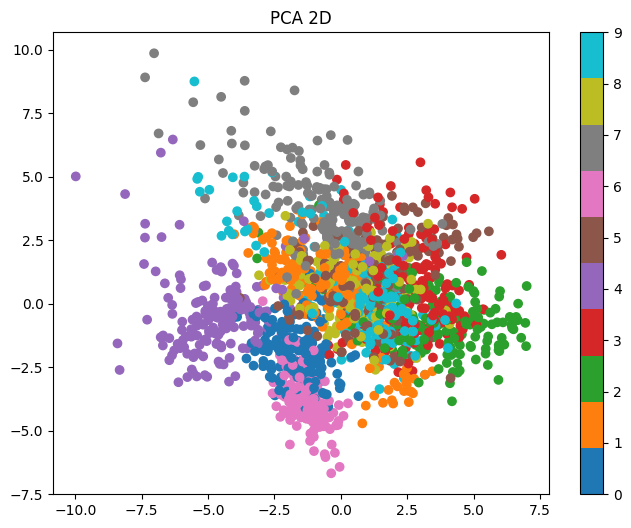

In [87]:
# We draw a scatter plot that represents this reduction on the two principal components:

# We create a 2D graph:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
plt.scatter(X_scaled_reduced_2[:, 0], X_scaled_reduced_2[:, 1], c=y, cmap='tab10')
plt.title("PCA 2D")
plt.colorbar()

# We print the graph:

plt.show()

As a conclusion from the graph, we can say that features 0, 4, and 6 are quite well defined, which suggests that they have specific patterns in the original data. Other features, such as 2 and 3, overlap considerably, which creates confusion.

PCA with reduction to 2 components has been useful to visualize the data in a 2-axis graph and draw certain conclusions from it. On the other hand, to work with the data we should determine the number of components to which to apply PCA reduction when the Cumulative Explained Variance reaches 99%.

In any case, for non-linear separations we already know that the t-SNE method is better.

#### t-SNE

Now we will perform dimensionality reduction using t-SNE on the MNIST dataset. We will reduce it to two components and set a random seed to 0.

We will draw a scatter plot representing this reduction on the two dimensions. We will color each point according to the number it represents, that is, the y variable or label in the case of the DataFrame.

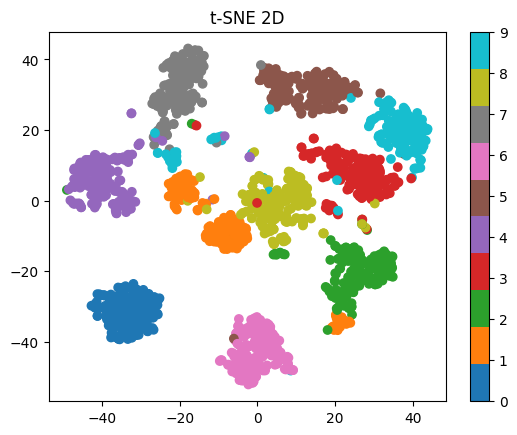

In [88]:
# We apply t-SNE with reduction to 2 components:

tsne = TSNE(n_components = 2, random_state=0)
X_tsne = tsne.fit_transform(X_scaled)

# We print the graph:

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
plt.title("t-SNE 2D")
plt.colorbar()
plt.show()

Without a doubt, this dimensionality reduction method is much better and more useful for our dataset than PCA. All the features have been perfectly defined, as can be observed in the graph.

#### PCA & t-SNE

Next, we will combine both techniques. We will perform dimensionality reduction using PCA with 10 components and subsequently apply t-SNE on the resulting dataset. For t-SNE, we will again reduce to two components and set a random seed to 0.

We will draw a scatter plot representing this reduction on the two dimensions. We will color each point according to the number it represents, that is, the y variable or label in the case of the DataFrame.

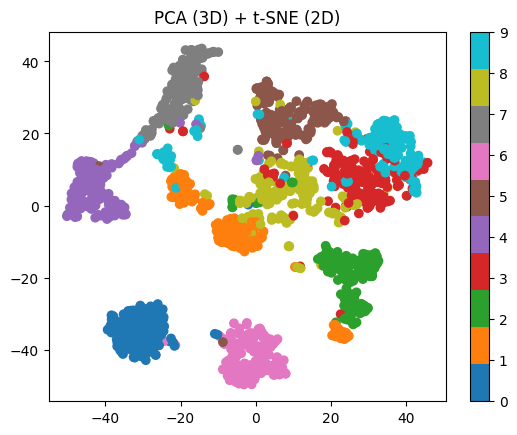

In [89]:
# We apply PCA with 10 components:

pca_10 = PCA(n_components=10)
X_pca_10 = pca_10.fit_transform(X_scaled)

# We apply t-SNE on the resulting dataset reducing it to two components and setting a random seed to 0:

tsne_comb = TSNE(n_components=2, random_state=0)
X_comb = tsne_comb.fit_transform(X_pca_10)

# We draw a scatter plot that represents this reduction on the two dimensions:

plt.figure()
plt.scatter(X_comb[:, 0], X_comb[:, 1], c=y, cmap='tab10')
plt.title("PCA (3D) + t-SNE (2D)")
plt.colorbar()
plt.show()

This last system gives quite a good result (not as good as t-SNE with 2 components, but close) and is computationally much faster, so it can be a good solution when working with large datasets.